<a href="https://colab.research.google.com/github/ben-g26/Rusting_Rivers/blob/main/Rusting_Rivers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arctic River Rusting Detection using AlphaEarth Embeddings

This notebook implements a workflow for detecting and characterising river rusting across Arctic environments using Google’s AlphaEarth satellite embeddings. River rusting is an emerging environmental problem linked to permafrost thaw, where the mobilisation of iron and other metals causes rivers to develop strong orange-brown discolouration. Existing approaches often rely on visual interpretation of RGB satellite imagery or manually selected spectral bands, which limits their scalability across large Arctic regions.

The main objective of this notebook is to test whether rusting rivers follow a coherent trajectory in high-dimensional embedding space. To do this, pixel-level 64-dimensional AlphaEarth embeddings are extracted from manually delineated river polygons, compared between 2017 and 2020, and analysed using Principal Component Analysis (PCA) and Singular Value Decomposition (SVD). The aim is to learn a “rusting direction” in embedding-change space that can distinguish rusting-like temporal change from normal variability in control rivers.

In the longer term, this framework could support Arctic-scale monitoring by projecting unseen river segments onto the learned rusting axis and assigning rusting-likelihood scores. This would help build a larger database of affected rivers and improve monitoring of the environmental risks associated with permafrost-driven metal mobilisation.

#### Getting Started

Start by connecting the notebook to google drive to access a directory. All necessary files should have been uploaded to that directory beforehand. We also install required packages and start an emssions tracker for this notebook's environmental footprint (not activated here to simplify outputs).

In [3]:
from google.colab import drive
drive.mount('/content/drive')
# !pip install rasterio matplotlib numpy
# !pip install codecarbon

# from codecarbon import EmissionsTracker

# tracker = EmissionsTracker()
# tracker.start()

Mounted at /content/drive


Below is an exploration of the extracted dataset. Code cells do repeat as the approach is refined throughout this notebook, so a full workflow explanation is only explained *once* at the end of the exploration. <br><br>
# Exploration of AlphaEarth Embeddings

The interested viewer can read along this first part to understand how the final methodology came to be, starting with a simple visual check of the data we are analizing (single layer for Agashashok river in 2017).

Original shape: (1152, 322, 619)

Final cleaned shape: (9, 64, 322, 619)
Years retained: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


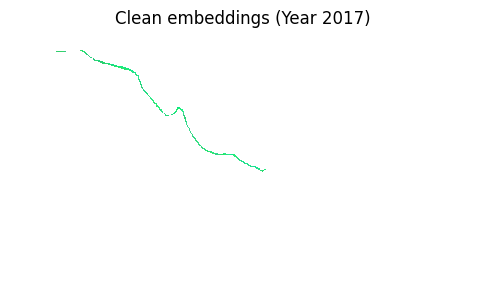

In [8]:
#### START HERE

import rasterio
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# ------------------------------------------------------------
# 1. LOAD
# ------------------------------------------------------------
path = "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif"
src = rasterio.open(path)

data = src.read()  # (bands, y, x)
names = list(src.descriptions)

print("Original shape:", data.shape)

# ------------------------------------------------------------
# 2. EXTRACT YEARS FROM BAND NAMES
# ------------------------------------------------------------
def extract_year(name):
    if name is None:
        return None
    m = re.search(r"_(\d{4})_", name)
    return int(m.group(1)) if m else None

years = np.array([extract_year(n) for n in names])

# ------------------------------------------------------------
# 3. GROUP BANDS BY YEAR (CRITICAL FIX)
# ------------------------------------------------------------
year_groups = defaultdict(list)

for i, y in enumerate(years):
    if y is not None:
        year_groups[y].append(i)

# print("\nBands per year:")
# for y in sorted(year_groups.keys()):
#     print(y, "→", len(year_groups[y]))

# ------------------------------------------------------------
# 4. BUILD CLEAN YEARLY STACK (NO POSITION ASSUMPTIONS)
# ------------------------------------------------------------
clean_years = []
clean_blocks = []

for y in sorted(year_groups.keys()):

    idx = year_groups[y]

    # skip empty or corrupted years
    if len(idx) == 0:
        continue

    # ensure consistent ordering
    idx = sorted(idx)

    # enforce 64-band structure (truncate if needed, safer than crash)
    if len(idx) < 64:
        print(f"Skipping incomplete year {y} (only {len(idx)} bands)")
        continue

    idx = idx[:64]

    # extract year block
    year_block = data[idx, :, :]

    clean_blocks.append(year_block)
    clean_years.append(y)

clean_reshaped = np.stack(clean_blocks)

print("\nFinal cleaned shape:", clean_reshaped.shape)
print("Years retained:", clean_years)

# ------------------------------------------------------------
# 5. QUICK VISUAL CHECK
# ------------------------------------------------------------
img = clean_reshaped[0]

rgb = np.stack([
    img[0],   # A01
    img[16],  # A16
    img[8]    # A09
], axis=-1)

# normalize safely
rgb_min = np.nanmin(rgb)
rgb_max = np.nanmax(rgb)
rgb = (rgb - rgb_min) / (rgb_max - rgb_min + 1e-9)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title(f"Clean embeddings (Year {clean_years[0]})")
plt.axis("off")
plt.show()

Next, we plot a representation of year-on-year changes in embedding layers accross the observation timeline.


PROCESSING: River_A
Raster bands: 1152

Bands per year:
2017 → 128
2018 → 128
2019 → 128
2020 → 128
2021 → 128
2022 → 128
2023 → 128
2024 → 128
2025 → 128


/tmp/ipykernel_1367/3556439218.py:92: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(flat, axis=1)



Final years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Mean matrix shape: (9, 64)


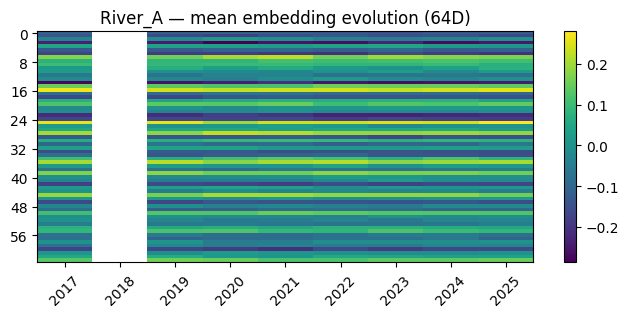


PROCESSING: River_B
Raster bands: 576

Bands per year:
2017 → 64
2018 → 64
2019 → 64
2020 → 64
2021 → 64
2022 → 64
2023 → 64
2024 → 64
2025 → 64

Final years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Mean matrix shape: (9, 64)


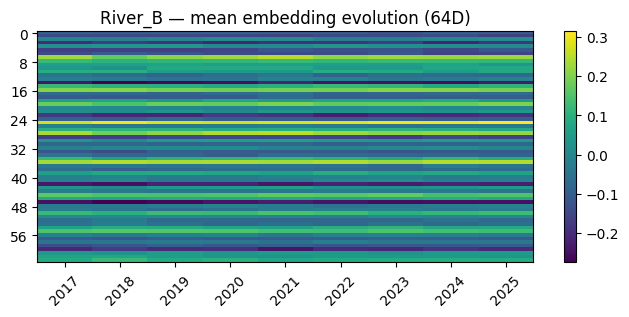


PROCESSING: River_C
Raster bands: 576

Bands per year:
2017 → 64
2018 → 64
2019 → 64
2020 → 64
2021 → 64
2022 → 64
2023 → 64
2024 → 64
2025 → 64

Final years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Mean matrix shape: (9, 64)


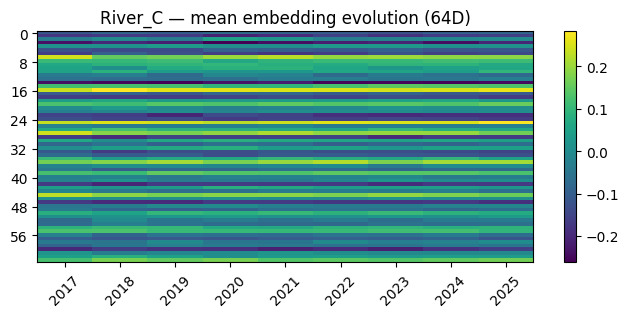


SUMMARY
River_A
  years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
  shape: (9, 64)
River_B
  years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
  shape: (9, 64)
River_C
  years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
  shape: (9, 64)


In [ ]:
### Heatmap Representation of Embeddings from 2017 -> 2025
import rasterio
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# ------------------------------------------------------------
# 1. INPUT PATHS
# ------------------------------------------------------------
paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif"
}

river_results = {}

# ------------------------------------------------------------
# 2. PROCESS EACH RIVER (SAFE + CORRECTED INDEXING)
# ------------------------------------------------------------
for river_name, path in paths.items():

    print("\n====================================================")
    print("PROCESSING:", river_name)
    print("====================================================")

    with rasterio.open(path) as src:

        names = list(src.descriptions)
        print("Raster bands:", src.count)

        # ----------------------------------------------------
        # EXTRACT YEARS
        # ----------------------------------------------------
        def extract_year(name):
            if name is None:
                return None
            m = re.search(r"_(\d{4})_", name)
            return int(m.group(1)) if m else None

        years = np.array([extract_year(n) for n in names])

        # ----------------------------------------------------
        # GROUP BANDS BY YEAR
        # ----------------------------------------------------
        year_groups = defaultdict(list)

        for i, y in enumerate(years):
            if y is not None:
                year_groups[y].append(i)

        print("\nBands per year:")
        for y in sorted(year_groups.keys()):
            print(y, "→", len(year_groups[y]))

        # ----------------------------------------------------
        # BUILD CLEAN YEARLY STACK (NO FULL RAM LOAD)
        # ----------------------------------------------------
        clean_years = []
        yearly_means = []

        for y in sorted(year_groups.keys()):

            idx = sorted(year_groups[y])

            # ------------------------------------------------
            # FIX 1: convert 0-based → 1-based indexing
            # ------------------------------------------------
            idx = [i + 1 for i in idx]

            # ------------------------------------------------
            # FIX 2: ensure valid raster band range
            # ------------------------------------------------
            idx = [i for i in idx if 1 <= i <= src.count]

            # ------------------------------------------------
            # enforce 64-band structure
            # ------------------------------------------------
            if len(idx) < 64:
                print(f"Skipping incomplete year {y} ({len(idx)} bands)")
                continue

            idx = idx[:64]

            # ------------------------------------------------
            # READ ONLY REQUIRED BANDS
            # ------------------------------------------------
            block = src.read(idx)  # (64, H, W)

            flat = block.reshape(64, -1)

            mean_vec = np.nanmean(flat, axis=1)

            yearly_means.append(mean_vec)
            clean_years.append(y)

        yearly_means = np.array(yearly_means)

        print("\nFinal years:", clean_years)
        print("Mean matrix shape:", yearly_means.shape)

        # ----------------------------------------------------
        # STORE RESULTS
        # ----------------------------------------------------
        river_results[river_name] = {
            "years": np.array(clean_years),
            "means": yearly_means
        }

        # ----------------------------------------------------
        # QUICK VISUAL CHECK
        # ----------------------------------------------------
        if len(yearly_means) > 0:

            plt.figure(figsize=(8,3))
            plt.imshow(yearly_means.T, aspect='auto', cmap='viridis')
            plt.yticks((0,8,16,24,32,40,48,56,))
            plt.xticks(range(len(clean_years)), clean_years, rotation=45)
            plt.title(f"{river_name} — mean embedding evolution (64D)")
            plt.colorbar()
            plt.show()

# ------------------------------------------------------------
# 3. SUMMARY
# ------------------------------------------------------------
print("\n====================================================")
print("SUMMARY")
print("====================================================")

for k, v in river_results.items():
    print(k)
    print("  years:", v["years"])
    print("  shape:", v["means"].shape)

We note that River A (Agashashok) has 128 layers, twice the expected 64. This reflects a duplication artefact of the Google Earth Engine extraction workflow, and is dealt in the rest of this notebook by only keeping one copy of each layer.<br><br/>
Embedding layers remainmostly consistent over the years observed, and any variation is difficult to resolve in this high dimensionality. To constrain the changes that might correlate to rusting, we will next examine differences between 2017 (before rusting) and 2020 (peak rusting). Rusting extent of the reference rivers is taken from O'Donell et al. (2025).

## Plot Changes in Embeddings Between 2017 and 2020


River_A
Years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
Shape: (9, 64)

River_B
Years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
Shape: (9, 64)

River_C
Years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
Shape: (9, 64)


[codecarbon INFO @ 18:30:38] Energy consumed for RAM : 0.000958 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:30:38] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:30:38] Energy consumed for All CPU : 0.004072 kWh
[codecarbon INFO @ 18:30:38] 0.005030 kWh of electricity and 0.000000 L of water were used since the beginning.


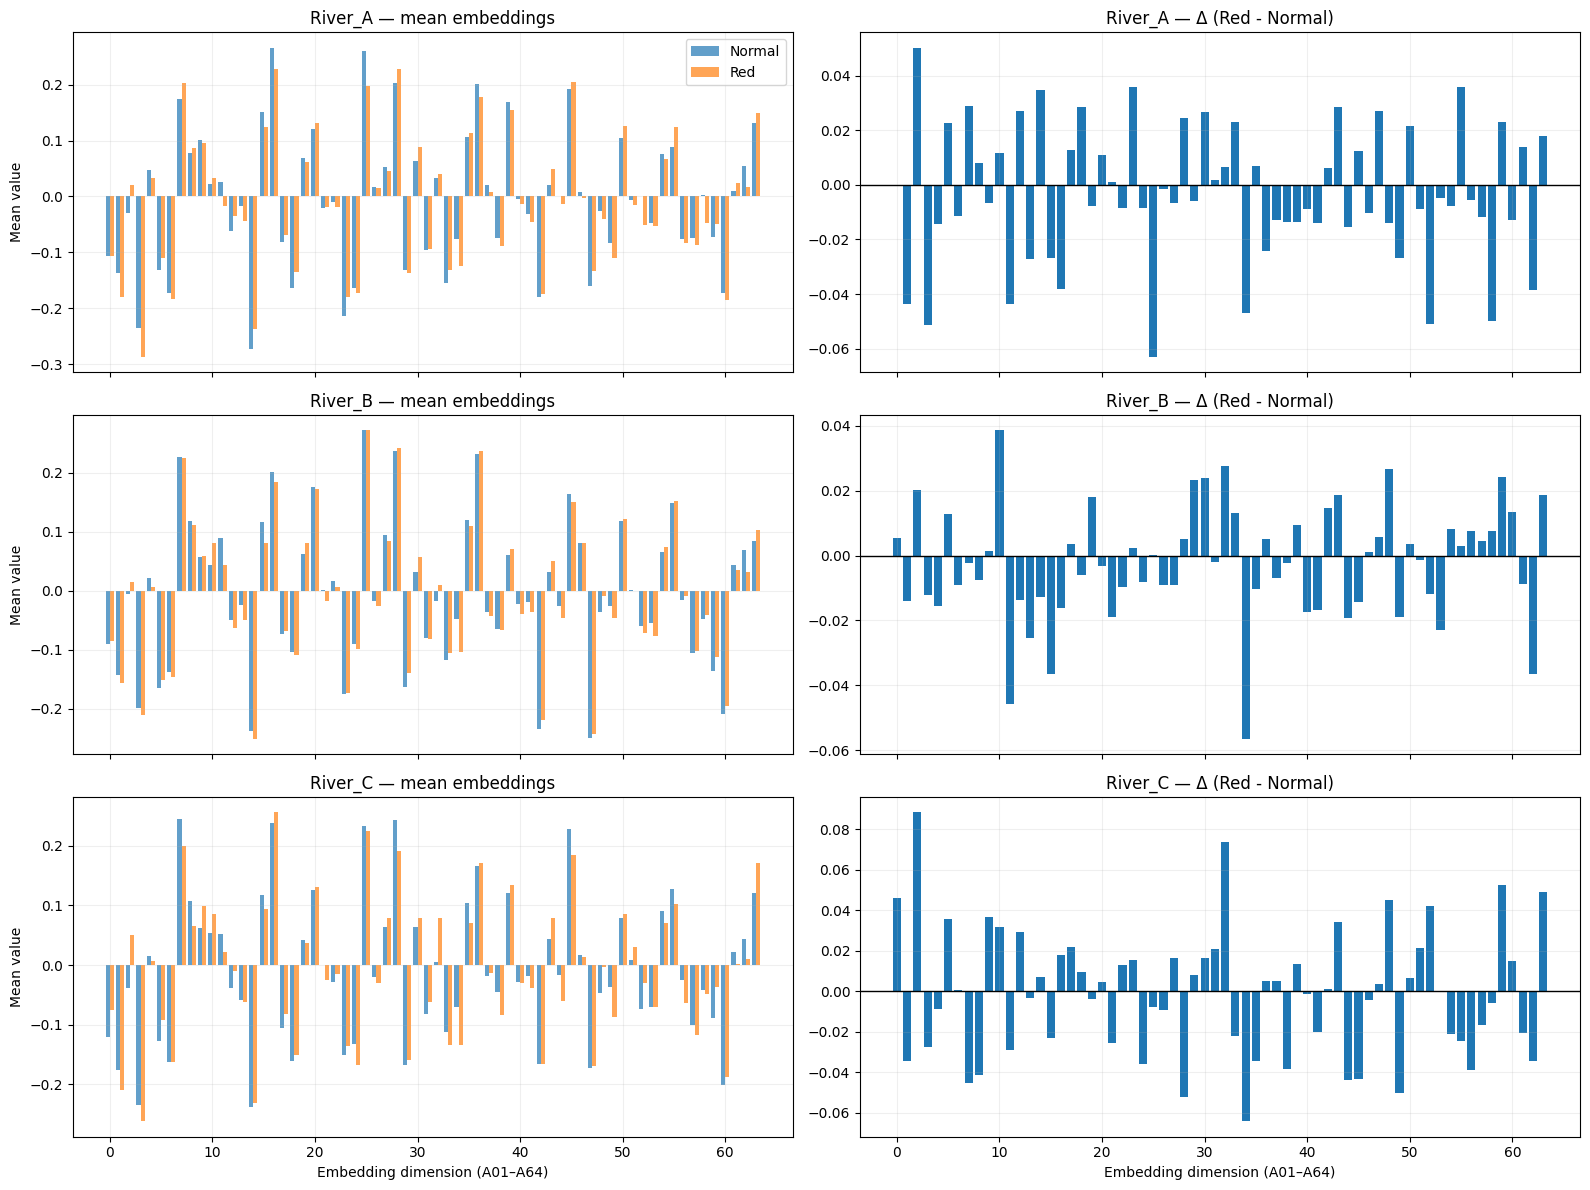


SUMMARY METRICS

 River_A
  ||Δ||: 0.20168142386175866
  Top dims: ['A26', 'A04', 'A53', 'A03', 'A59', 'A35', 'A02']

 River_B
  ||Δ||: 0.1427879230223749
  Top dims: ['A35', 'A12', 'A11', 'A16', 'A63', 'A33', 'A49']

 River_C
  ||Δ||: 0.2529455413423738
  Top dims: ['A03', 'A33', 'A35', 'A60', 'A29', 'A50', 'A64']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# MULTI-RIVER EMBEDDING CHANGE COMPARISON (A, B, C)
# expects:
# river_results = {
#   "River_A": {"years": ..., "means": (n,64)},
#   "River_B": {...},
#   "River_C": {...}
# }
# ------------------------------------------------------------

rivers = ["River_A", "River_B", "River_C"]

# ------------------------------------------------------------
# USER-DEFINED REGIMES (EDIT THESE)
# ------------------------------------------------------------
normal_years = np.array([2017])
red_years = np.array([2020])

dims = np.arange(64)

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

# ------------------------------------------------------------
# LOOP OVER RIVERS
# ------------------------------------------------------------
for r_i, river_name in enumerate(rivers):

    years = np.array(river_results[river_name]["years"])
    means = np.array(river_results[river_name]["means"])

    print("\n==============================")
    print(river_name)
    print("Years:", years)
    print("Shape:", means.shape)

    # --------------------------------------------------------
    # MASK REGIMES
    # --------------------------------------------------------
    normal_mask = np.isin(years, normal_years)
    red_mask = np.isin(years, red_years)

    if np.sum(normal_mask) == 0 or np.sum(red_mask) == 0:
        print("Skipping (missing regime years)")
        continue

    # --------------------------------------------------------
    # COMPUTE MEANS
    # --------------------------------------------------------
    normal_vec = np.nanmean(means[normal_mask], axis=0)
    red_vec = np.nanmean(means[red_mask], axis=0)

    delta = red_vec - normal_vec

    # --------------------------------------------------------
    # PLOT 1: SIDE-BY-SIDE COMPARISON
    # --------------------------------------------------------
    ax = axes[r_i, 0]

    ax.bar(dims - 0.2, normal_vec, width=0.4, label="Normal", alpha=0.7)
    ax.bar(dims + 0.2, red_vec, width=0.4, label="Red", alpha=0.7)

    ax.set_title(f"{river_name} — mean embeddings")
    ax.set_ylabel("Mean value")
    ax.grid(alpha=0.2)

    if r_i == 0:
        ax.legend()

    # --------------------------------------------------------
    # PLOT 2: DELTA
    # --------------------------------------------------------
    ax2 = axes[r_i, 1]

    ax2.bar(dims, delta)

    ax2.axhline(0, color="black", linewidth=1)
    ax2.set_title(f"{river_name} — Δ (Red - Normal)")
    ax2.grid(alpha=0.2)

# ------------------------------------------------------------
# GLOBAL LABELS
# ------------------------------------------------------------
axes[2, 0].set_xlabel("Embedding dimension (A01–A64)")
axes[2, 1].set_xlabel("Embedding dimension (A01–A64)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# OPTIONAL: SUMMARY NUMBERS
# ------------------------------------------------------------
print("\n==============================")
print("SUMMARY METRICS")
print("==============================")

for river_name in rivers:

    years = np.array(river_results[river_name]["years"])
    means = np.array(river_results[river_name]["means"])

    normal_mask = np.isin(years, normal_years)
    red_mask = np.isin(years, red_years)

    if np.sum(normal_mask) == 0 or np.sum(red_mask) == 0:
        continue

    normal_vec = np.nanmean(means[normal_mask], axis=0)
    red_vec = np.nanmean(means[red_mask], axis=0)
    delta = red_vec - normal_vec

    print("\n", river_name)
    print("  ||Δ||:", np.linalg.norm(delta))

    top = np.argsort(np.abs(delta))[::-1][:7]
    print("  Top dims:", [f"A{i+1:02d}" for i in top])

We observe that in all three rivers, layer 35 is present in the top 6 layers with the most change. However, this result is quite weak and could be the product of chance, so we use further methods to identify a direction of change.

### Plot Trajectory in PCA Space of Mean River Embeddings

For each layer, we average the embedding score over all pixels, and timelines for each river are plotted in a reduced 2D plot.

River_A: removed 1 bad rows
River_B: removed 0 bad rows
River_C: removed 0 bad rows

Final PCA shape: (26, 64)
Explained variance: [0.36305834 0.17501914]


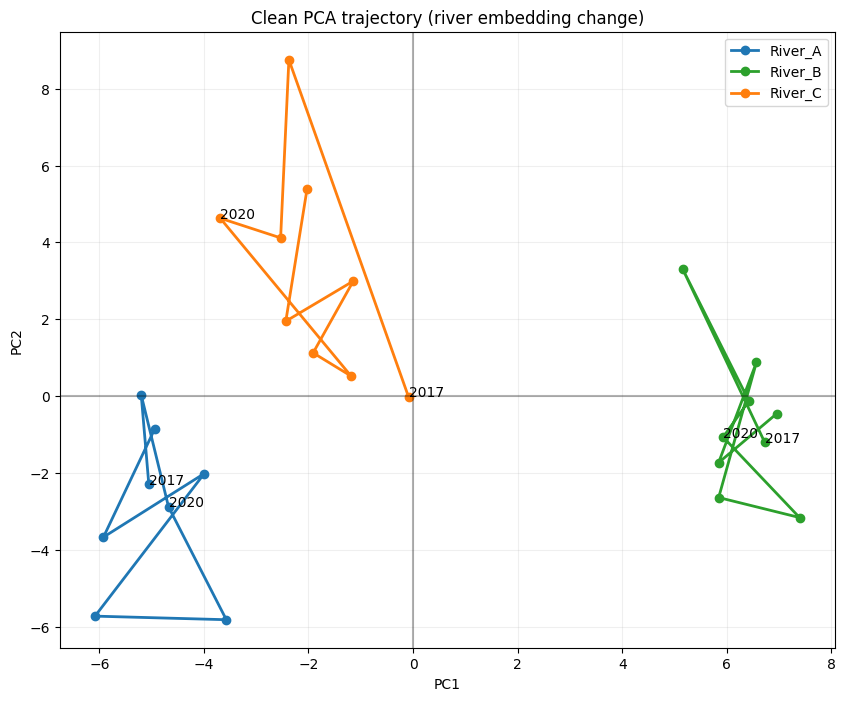

In [ ]:
# Trajectory in PCA space accross timeline (2017-2025)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

rivers = ["River_A", "River_B", "River_C"]

all_data = []
all_labels = []
all_years = []

for r in rivers:

    years = np.array(river_results[r]["years"])
    means = np.array(river_results[r]["means"], dtype=np.float64)

    # --------------------------------------------------------
    # KEEP ONLY VALID ROWS
    # --------------------------------------------------------
    valid_mask = np.isfinite(means).all(axis=1)

    years_clean = years[valid_mask]
    means_clean = means[valid_mask]

    print(f"{r}: removed {len(years) - len(years_clean)} bad rows")

    all_data.append(means_clean)
    all_labels.extend([r] * len(years_clean))
    all_years.extend(years_clean)

all_data = np.vstack(all_data)
all_labels = np.array(all_labels)
all_years = np.array(all_years)

print("\nFinal PCA shape:", all_data.shape)

# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------
X = StandardScaler().fit_transform(all_data)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance:", pca.explained_variance_ratio_)

# ------------------------------------------------------------
# PLOT TRAJECTORIES
# ------------------------------------------------------------
plt.figure(figsize=(10,8))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange"
}

for r in rivers:

    mask = (all_labels == r)
    yrs = all_years[mask]
    coords = X_pca[mask]

    order = np.argsort(yrs)
    yrs = yrs[order]
    coords = coords[order]

    plt.plot(coords[:,0], coords[:,1],
             marker="o",
             linewidth=2,
             label=r,
             color=colors[r])

    for i, y in enumerate(yrs):
        if y in [2017, 2020]:
            plt.text(coords[i,0], coords[i,1], str(y), fontsize=10)

plt.axhline(0, alpha=0.3, color="black")
plt.axvline(0, alpha=0.3, color="black")

plt.title("Clean PCA trajectory (river embedding change)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

There is little pattern in the trajectory accross rusting rivers. This is likely due to averaging over all pixels before performing PCA. An alternative is explored later on.

### Plot 2017 -> 2020 Change in PCA Space for Mean Embedding Layers
Next, we investigate whether fitting PCA on only 2 years and all rivers can better isolate a rusting signal than the full timeseries.

Explained variance: [0.44488321 0.27344431]


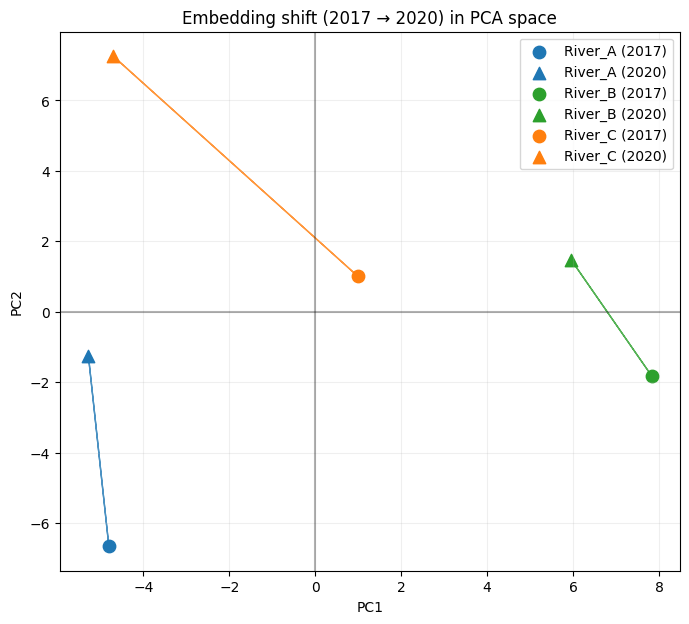

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

rivers = ["River_A", "River_B", "River_C"]

results = {}
dims = np.arange(64)

# ------------------------------------------------------------
# 1. EXTRACT 2017 / 2020 MEANS
# ------------------------------------------------------------
for r in rivers:

    years = np.array(river_results[r]["years"])
    means = np.array(river_results[r]["means"], dtype=np.float64)

    m2017 = (years == 2017)
    m2020 = (years == 2020)

    if np.sum(m2017) == 0 or np.sum(m2020) == 0:
        print(f"{r}: missing 2017 or 2020")
        continue

    v2017 = np.nanmean(means[m2017], axis=0)
    v2020 = np.nanmean(means[m2020], axis=0)

    results[r] = {
        "2017": v2017,
        "2020": v2020
    }

# ------------------------------------------------------------
# 2. PCA SPACE (ONLY 6 POINTS TOTAL)
# ------------------------------------------------------------
X = []
labels = []
r_labels = []

for r in results:

    X.append(results[r]["2017"])
    X.append(results[r]["2020"])

    labels.append("2017")
    labels.append("2020")

    r_labels.append(r)
    r_labels.append(r)

X = np.array(X)

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

# ------------------------------------------------------------
# 3. PLOT WITH ARROWS (COLOURED BY RIVER)
# ------------------------------------------------------------
plt.figure(figsize=(8,7))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange"
}

for r in results:

    idx_2017 = list(results.keys()).index(r) * 2
    idx_2020 = idx_2017 + 1

    x1, y1 = X_pca[idx_2017]
    x2, y2 = X_pca[idx_2020]

    c = colors[r]

    # points
    plt.scatter(x1, y1, color=c, s=80, label=f"{r} (2017)")
    plt.scatter(x2, y2, color=c, s=80, marker="^", label=f"{r} (2020)")

    # arrow
    plt.arrow(
        x1, y1,
        x2 - x1,
        y2 - y1,
        color=c,
        head_width=0.03,
        length_includes_head=True,
        alpha=0.8
    )

    # # labels
    # plt.text(x1, y1, f"{r}-2017", fontsize=9)
    # plt.text(x2, y2, f"{r}-2020", fontsize=9)

# ------------------------------------------------------------
# 4. STYLING
# ------------------------------------------------------------
plt.axhline(0, color="black", alpha=0.3)
plt.axvline(0, color="black", alpha=0.3)

plt.title("Embedding shift (2017 → 2020) in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)

# clean legend (avoid duplicates)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="best")

plt.show()

Change vectors seem to align in PC1-PC2 space, which is very encouraging! These results are derived from river means though, so a pixel-level analysis is required for statistically robust PCA transforms.

### Perform PCA on the Embedding Changes at Pixel Level
Next, we investigate whether the model performs well when performing PCA on the deltas rather than both sets of years. Here, we perform PCA on all pixels rather than averages. If rivers follow a unified rusting direction captured by PC1 and PC2, point clouds should overlap in the plot.<br><br/>

We also introduce controls (in grey) which are taken nearby each training river.


Processing River_A


[codecarbon INFO @ 20:59:09] Energy consumed for RAM : 0.025697 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:59:09] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:59:09] Energy consumed for All CPU : 0.109228 kWh
[codecarbon INFO @ 20:59:09] 0.134924 kWh of electricity and 0.000000 L of water were used since the beginning.


River_A: pixels = 1382

Processing River_B
River_B: pixels = 495

Processing River_C


[codecarbon INFO @ 20:59:24] Energy consumed for RAM : 0.025738 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:59:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:59:24] Energy consumed for All CPU : 0.109405 kWh
[codecarbon INFO @ 20:59:24] 0.135143 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:59:39] Energy consumed for RAM : 0.025780 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:59:39] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:59:39] Energy consumed for All CPU : 0.109582 kWh
[codecarbon INFO @ 20:59:39] 0.135361 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:59:54] Energy consumed for RAM : 0.025821 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:59:54] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:59:54] Energy consumed for All CPU

River_C: pixels = 8430

Processing Control_1


[codecarbon INFO @ 21:00:09] Energy consumed for RAM : 0.025863 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:00:09] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:00:09] Energy consumed for All CPU : 0.109936 kWh
[codecarbon INFO @ 21:00:09] 0.135799 kWh of electricity and 0.000000 L of water were used since the beginning.


Control_1: pixels = 4163

Processing Control_2
Control_2: pixels = 536

Processing Control_3
Control_3: pixels = 748

Balanced sample size per river: 495

Final balanced dataset: (2970, 64)

Explained variance: [0.25322386 0.14697354]

 Rusting axis (64D):
[ 0.19709898 -0.03865408  0.18107016  0.03345251  0.02145754  0.06779412
  0.0351043  -0.20888423 -0.18225578  0.12351102  0.06956632  0.07984884
  0.0850926   0.16091438 -0.06541032 -0.02793541  0.21485567  0.10116656
 -0.03801154 -0.031787    0.04807174 -0.10868588  0.15688222  0.01430637
 -0.17298799  0.11402414 -0.07624721  0.11052869 -0.223264    0.03896285
 -0.06672854  0.11981109  0.2028661  -0.16029755 -0.08253386 -0.19952916
  0.12956501  0.13527342 -0.16118861  0.03718957  0.06827413 -0.08667274
 -0.02823717  0.06440267 -0.15107698 -0.18535182  0.02740928 -0.10286766
  0.15383927 -0.09130161 -0.09254686  0.14616319  0.22805751  0.10960123
 -0.0975588  -0.17766521 -0.170486   -0.10530972  0.05928491  0.13275693
  0.12820678 

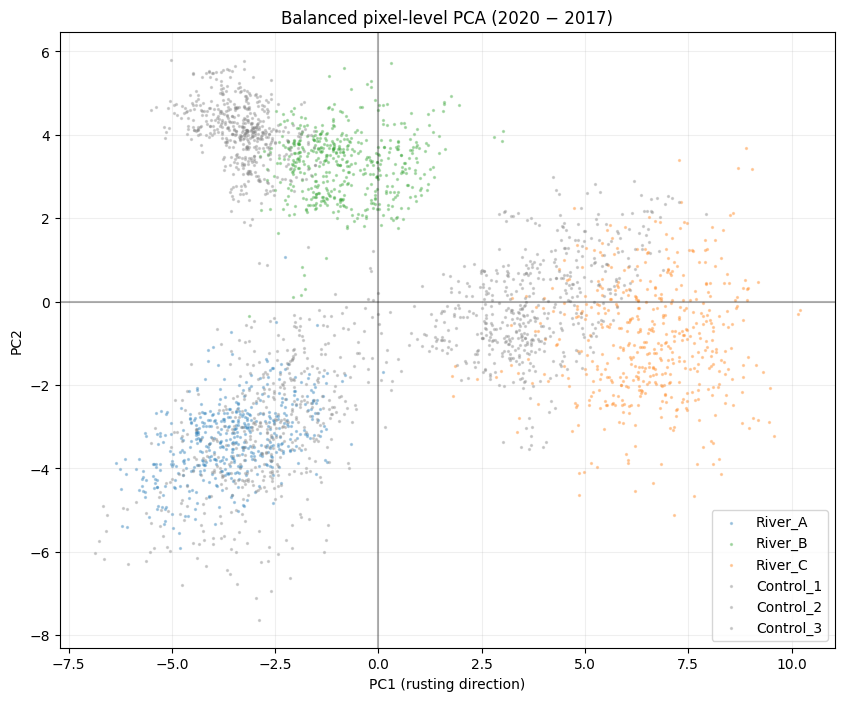


===== RIVER STATISTICS =====
River_A: mean=-3.528423, std=1.162625
River_B: mean=-0.801672, std=1.077826
River_C: mean=6.561668, std=1.389012
Control_1: mean=-2.694409, std=1.397578
Control_2: mean=-3.307783, std=0.718042
Control_3: mean=3.770619, std=1.326507


In [ ]:
## PCA on deltas
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import defaultdict
import re

# ------------------------------------------------------------
# INPUT PATHS
# ------------------------------------------------------------
paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif",
    "Control_1": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_1.tif",
    "Control_2": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_2.tif",
    "Control_3": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_4.tif"
}

rivers = list(paths.keys())

river_pixels = {}
river_labels = {}

# ------------------------------------------------------------
# 1. EXTRACT PIXEL-LEVEL DELTAS PER RIVER
# ------------------------------------------------------------
for r, path in paths.items():

    print(f"\nProcessing {r}")

    with rasterio.open(path) as src:

        names = list(src.descriptions)

        def extract_year(name):
            if name is None:
                return None
            m = re.search(r"_(\d{4})_", name)
            return int(m.group(1)) if m else None

        years = np.array([extract_year(n) for n in names])

        groups = defaultdict(list)
        for i, y in enumerate(years):
            if y is not None:
                groups[y].append(i)

        if 2017 not in groups or 2020 not in groups:
            print(f"{r}: missing 2017 or 2020")
            continue

        idx17 = sorted(groups[2017])[:64]
        idx20 = sorted(groups[2020])[:64]

        idx17 = [i + 1 for i in idx17 if i + 1 <= src.count]
        idx20 = [i + 1 for i in idx20 if i + 1 <= src.count]

        img17 = src.read(idx17)
        img20 = src.read(idx20)

        delta = img20 - img17   # (64, H, W)

        X = delta.reshape(64, -1).T  # (pixels, 64)

        valid = np.isfinite(X).all(axis=1)
        X = X[valid]

        river_pixels[r] = X

        print(f"{r}: pixels = {X.shape[0]}")

# ------------------------------------------------------------
# 2. BALANCE SAMPLE SIZE ACROSS RIVERS
# ------------------------------------------------------------
min_n = min([v.shape[0] for v in river_pixels.values()])

print("\nBalanced sample size per river:", min_n)

X_all = []
labels = []

for r in rivers:

    X = river_pixels[r]

    # random subsample
    idx = np.random.choice(X.shape[0], min_n, replace=False)

    X_bal = X[idx]

    X_all.append(X_bal)
    labels.extend([r] * min_n)

X_all = np.vstack(X_all)
labels = np.array(labels)

print("\nFinal balanced dataset:", X_all.shape)

# ------------------------------------------------------------
# 3. STANDARDISE
# ------------------------------------------------------------
X_all = StandardScaler().fit_transform(X_all)

# ------------------------------------------------------------
# 4. PCA
# ------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

print("\nExplained variance:", pca.explained_variance_ratio_)

rusting_axis = pca.components_[0]
print("\n Rusting axis (64D):")
print(rusting_axis)

# ------------------------------------------------------------
# 5. VISUALISATION
# ------------------------------------------------------------
plt.figure(figsize=(10,8))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange",
    "Control_1": "tab:grey",
    "Control_2": "tab:grey",
    "Control_3": "tab:grey"
}

for r in rivers:
    mask = (labels == r)

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=2,
        alpha=0.3,
        label=r,
        color=colors[r]
    )

plt.axhline(0, color="black", alpha=0.3)
plt.axvline(0, color="black", alpha=0.3)

plt.title("Balanced pixel-level PCA (2020 − 2017)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

# ------------------------------------------------------------
# 6. RIVER PROJECTIONS
# ------------------------------------------------------------
print("\n===== RIVER STATISTICS =====")

for r in rivers:
    mask = (labels == r)
    proj = X_pca[mask, 0]

    print(f"{r}: mean={proj.mean():.6f}, std={proj.std():.6f}")

We observe that rusting rivers do not overlap and rusting direction is not capture with this method. Instead, we see strong overlap of rivers with their respective control streams located nearby, suggesting a strong influence of geography and location-specific differences between 2017 and 2020 on PC1 and PC2. Similar results (not shown here) are observed when performing PCA on only control rivers or only rusting rivers, and plotting remaining rivers in that PCA space.

# Performing PCA all River Pixels, and Subsequently Plotting and Change Vectors

Out of all approacheds, this one resulted is the most robust and procuces a consistent result leading to the identification of a universal rusting direction in 64D.




Processing River_A
River_A: pixels used = 1382

Processing River_B
River_B: pixels used = 495

Processing River_C
River_C: pixels used = 8430

Global dataset shape: (20614, 64)
Balanced samples per (river, year): 495
Balanced dataset: (2970, 64)

Explained variance ratio: [0.25557681 0.16829192]


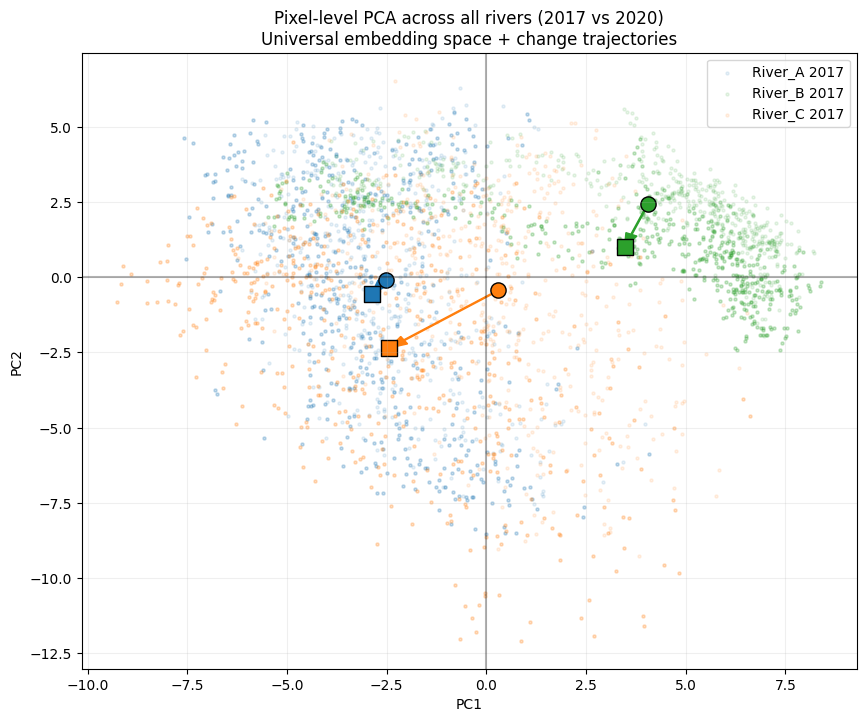

In [ ]:
### PCA on all pixels, plotting change vectors
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import defaultdict
import re

# ============================================================
# 1. INPUT PATHS
# ============================================================
paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif"
}

rivers = list(paths.keys())

# Storage for pixel-level samples
data_blocks = []
labels_river = []
labels_year = []

# ============================================================
# 2. LOAD PIXELS (NO MEANS, NO DELTAS)
# ============================================================
for r, path in paths.items():

    print(f"\nProcessing {r}")

    with rasterio.open(path) as src:

        names = list(src.descriptions)

        def extract_year(name):
            if name is None:
                return None
            m = re.search(r"_(\d{4})_", name)
            return int(m.group(1)) if m else None

        years = np.array([extract_year(n) for n in names])

        groups = defaultdict(list)
        for i, y in enumerate(years):
            if y is not None:
                groups[y].append(i)

        # only years of interest
        if 2017 not in groups or 2020 not in groups:
            print(f"{r}: missing 2017 or 2020")
            continue

        idx17 = [i + 1 for i in sorted(groups[2017])[:64] if i + 1 <= src.count]
        idx20 = [i + 1 for i in sorted(groups[2020])[:64] if i + 1 <= src.count]

        img17 = src.read(idx17)  # (64, H, W)
        img20 = src.read(idx20)

        # ========================================================
        # FLATTEN TO PIXELS (NO AGGREGATION)
        # ========================================================
        X17 = img17.reshape(64, -1).T
        X20 = img20.reshape(64, -1).T

        # keep only pixels valid in BOTH years
        valid = np.isfinite(X17).all(axis=1) & np.isfinite(X20).all(axis=1)

        X17 = X17[valid]
        X20 = X20[valid]

        print(f"{r}: pixels used = {X17.shape[0]}")

        # store
        data_blocks.append(X17)
        data_blocks.append(X20)

        labels_river += [r] * len(X17)
        labels_year += [2017] * len(X17)

        labels_river += [r] * len(X20)
        labels_year += [2020] * len(X20)

# ============================================================
# 3. STACK GLOBAL DATASET
# ============================================================
X = np.vstack(data_blocks)
labels_river = np.array(labels_river)
labels_year = np.array(labels_year)

print("\nGlobal dataset shape:", X.shape)

# ============================================================
# 4. BALANCE SAMPLE SIZE (PER RIVER + YEAR)
# ============================================================
min_n = min([
    np.sum((labels_river == r) & (labels_year == y))
    for r in rivers
    for y in [2017, 2020]
])

print("Balanced samples per (river, year):", min_n)

balanced_X = []
balanced_river = []
balanced_year = []

for r in rivers:
    for y in [2017, 2020]:

        mask = (labels_river == r) & (labels_year == y)
        X_sub = X[mask]

        if len(X_sub) == 0:
            continue

        idx = np.random.choice(len(X_sub), min_n, replace=False)

        balanced_X.append(X_sub[idx])
        balanced_river += [r] * min_n
        balanced_year += [y] * min_n

X_bal = np.vstack(balanced_X)
balanced_river = np.array(balanced_river)
balanced_year = np.array(balanced_year)

print("Balanced dataset:", X_bal.shape)

# ============================================================
# 5. STANDARDISE
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bal)

# ============================================================
# 6. PCA ON ALL PIXELS (BOTH YEARS, ALL RIVERS)
# ============================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)

# ============================================================
# 7. VISUALISATION
# ============================================================
plt.figure(figsize=(10, 8))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange"
}

# scatter by river + year
for r in rivers:
    for y, alpha in [(2017, 0.1), (2020, 0.25)]:

        mask = (balanced_river == r) & (balanced_year == y)

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=5,
            alpha=alpha,
            color=colors[r],
            label=f"{r} {y}" if y == 2017 else None
        )

# ============================================================
# MEAN SHIFT ARROWS (in PCA space)
# ============================================================
for r in rivers:

    p17 = X_pca[(balanced_river == r) & (balanced_year == 2017)]
    p20 = X_pca[(balanced_river == r) & (balanced_year == 2020)]

    if len(p17) == 0 or len(p20) == 0:
        continue

    m17 = p17.mean(axis=0)
    m20 = p20.mean(axis=0)

    plt.arrow(
        m17[0], m17[1],
        m20[0] - m17[0],
        m20[1] - m17[1],
        color=colors[r],
        width=0.03,
        head_width=0.3,
        length_includes_head=True
    )

    plt.scatter(m17[0], m17[1], color=colors[r], marker='o', s=120, edgecolor='black')
    plt.scatter(m20[0], m20[1], color=colors[r], marker='s', s=120, edgecolor='black')

# ============================================================
# FINAL STYLE
# ============================================================
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Pixel-level PCA across all rivers (2017 vs 2020)\nUniversal embedding space + change trajectories")

plt.grid(alpha=0.2)
plt.legend()
plt.show()

#### What do the arrows represent?
Because PCA was fit on all pixels from all rivers + both years, the axes reprensent:

- PC1 = direction of greatest variation across all river pixels and years
- PC2 = second-most important independent variation

So the arrows are expressed in a shared coordinate system of dominant variability in the dataset, making cross-river comparison valid.

#### How to interpret arrow direction

If arrows for different rivers point in similar directions:

The dominant change in embeddings is shared
all rivers undergo a similar transformation in feature space supports the idea of a “universal rusting direction”.

If they pointed in different directions, this would indicate that changes are river-specific and PCA structure is not dominated by a single “rusting axis”
or rusting is mixed with other environmental signals.

#### Cosine Similarity

The cosine similarity is computed:

$$cos(θ)=∣Δr1∣∣Δr2∣Δr1⋅Δr2$$


Interpretation:

~1.0 → almost identical change direction <br>
~0.5–0.8 → partially shared trend <br>
~0 or less -> unrelated changes

If consistently high values are observed across rivers, that is strong evidence of a shared structural shift.



PCA does not “know” about 2017 vs 2020
it only gives a coordinate system where structure is maximised. Therefore, a strong alignment of arrows is actually non-trivial evidence, because it emerges after projecting into a purely variance-driven space.


RIVER CHANGE DIRECTION ALIGNMENT (COSINE SIMILARITY)
River_A vs River_B: 0.9616
River_A vs River_C: 0.9580
River_B vs River_C: 0.8424

DIRECTION ANGLES IN PCA SPACE
River_A: angle = -128.34°
River_B: angle = -112.41°
River_C: angle = -145.01°


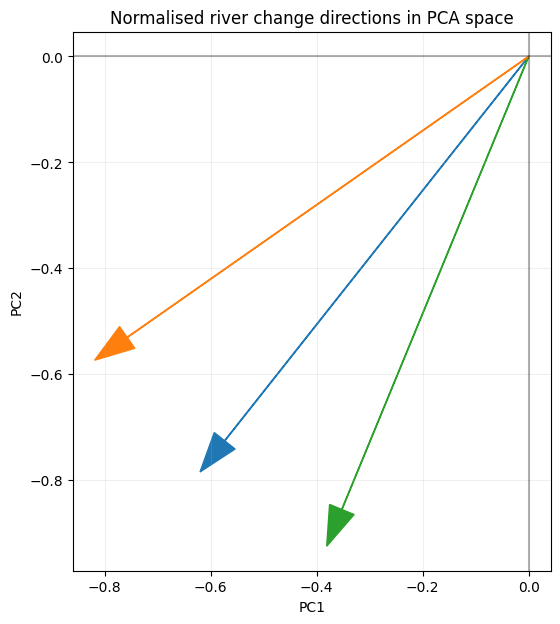

In [ ]:
### Cosine Similarity
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ASSUMES YOU HAVE ALREADY RUN THE PCA CELL AND HAVE:
# X_pca, balanced_river, balanced_year, rivers
# ============================================================

# ------------------------------------------------------------
# 1. COMPUTE MEAN DISPLACEMENT VECTORS PER RIVER
#    (in PCA space)
# ------------------------------------------------------------
mean_disp = {}

for r in rivers:

    p17 = X_pca[(balanced_river == r) & (balanced_year == 2017)]
    p20 = X_pca[(balanced_river == r) & (balanced_year == 2020)]

    if len(p17) == 0 or len(p20) == 0:
        continue

    v = p20.mean(axis=0) - p17.mean(axis=0)
    mean_disp[r] = v

# ------------------------------------------------------------
# 2. COSINE SIMILARITY BETWEEN RIVER CHANGE DIRECTIONS
# ------------------------------------------------------------
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

print("\n================================================")
print("RIVER CHANGE DIRECTION ALIGNMENT (COSINE SIMILARITY)")
print("================================================")

for i, r1 in enumerate(rivers):
    for r2 in rivers[i+1:]:
        if r1 in mean_disp and r2 in mean_disp:
            sim = cosine(mean_disp[r1], mean_disp[r2])
            print(f"{r1} vs {r2}: {sim:.4f}")

# ------------------------------------------------------------
# 3. ANGLE SUMMARY (INTERPRETABILITY)
# ------------------------------------------------------------
print("\n================================================")
print("DIRECTION ANGLES IN PCA SPACE")
print("================================================")

angles = {}

for r, v in mean_disp.items():
    angle = np.degrees(np.arctan2(v[1], v[0]))
    angles[r] = angle
    print(f"{r}: angle = {angle:.2f}°")

# ------------------------------------------------------------
# 4. VISUALISE NORMALISED DIRECTION VECTORS
# ------------------------------------------------------------
plt.figure(figsize=(7, 7))

origin = np.array([0.0, 0.0])

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange"
}

for r, v in mean_disp.items():

    v_norm = v / (np.linalg.norm(v) + 1e-12)

    plt.arrow(
        0, 0,
        v_norm[0], v_norm[1],
        head_width=0.05,
        length_includes_head=True,
        color=colors[r]
    )

    # plt.text(
    #     v_norm[0]*1.1,
    #     v_norm[1]*1.1,
    #     r,
    #     fontsize=12
    # )

plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)

plt.title("Normalised river change directions in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.gca().set_aspect('equal', adjustable='box')

plt.grid(alpha=0.2)
plt.show()

Cosine similarity between change vectors in very high (~90%), indicating a shared direction of change in PCA space.

# The Final Methodology, Including Controls

The principal component analysis (PCA) space was constructed using only the rust-affected rivers, while retaining observations from both 2017 and 2020. Control rivers were subsequently projected into this fixed PCA space without contributing to the estimation of the PCA basis vectors. <br><br/>
This approach was adopted to ensure that the dominant axes of variability reflected the structure and temporal evolution of the rusting systems themselves, rather than broader environmental differences introduced by unrelated control rivers. Including controls directly in PCA estimation risks allocating major components to inter-river variability associated with geomorphology, vegetation, sediment composition, or illumination conditions, potentially obscuring subtler temporal transitions associated with river rusting. By fitting PCA exclusively on rust-affected systems, the resulting embedding space is more sensitive to the dominant modes of variability within the phenomenon of interest, while still allowing controls to serve as external comparisons through out-of-sample projection. <br><br/>
A limitation of this approach is that the resulting PCA space becomes partially conditioned on the selected rusting rivers and may therefore underrepresent environmental variability outside the affected systems. Additionally, because PCA is applied to the original embeddings rather than temporal difference vectors, the resulting components still capture a mixture of spatial and temporal variability. Nevertheless, this framework provides a balance between interpretability, comparability, and sensitivity to rust-associated transitions.

### 1. Data Preparation and Pixel-Level Embedding Extraction

For each river:
- embedding pixels were sampled from AlphaEarth 64-dimensional annual embeddings
- only pixels valid in both 2017 and 2020 were retained
- pixel sets were balanced across rivers to ensure equal contribution during analysis

This produced paired embedding matrices:
- $x_{2017}$: pixel-level embeddings for 2017
- $x_{2020}$: corresponding embeddings for 2020


### 2. Temporal Change Analysis

An initial analysis of mean changes in embeddings was performed on the three rusting rivers.

$$
\Delta x = x_{2020} - x_{2017}
$$

where:

- $x$ is a 64-dimensional embedding
- $\Delta x$ represents mean movement accross 64 layers 2017 and 2020

There was no obvious changes in embedding structure over time during the study period.

In addition to temporal change over the entire period, embedding changes between 2017 and 2020 were examined to identify which embedding layers exhibited the largest magnitude of change. While no layer single-handedly explains rusting, layer 35 was in the top 6 among all rusting rivers.


### 3. PCA Representation Learning

Principal Component Analysis (PCA) was applied to the combined pixel-level embedding dataset (2017 and 2020 stacked together) to learn a low-dimensional representation of the embedding space.

This step was used to:

- reduce dimensionality of the 64-band embedding space
- provide a shared coordinate system for both years
- enable visualisation of temporal trajectories with vectors of mean displacement from 2017 to 2020

The resulting change vectors were consistent in direction within the resulting PC1/PC2 2D space. This indicates a common direction of change among rusting rivers, to be verified with controls (step 6).

This PCA space was used as a reference frame for all subsequent analysis.

### 4. Rust Axis Construction

A dominant direction of temporal change (“rust axis”) was estimated using Singular Value Decomposition (SVD) applied to the displacement vectors:

$$
r = \text{dominant direction of } \Delta x
$$

This axis represents the primary coherent direction of embedding change associated with river rusting behaviour across the sampled rivers.


### 5. Projection Scoring in PCA Space and Control Rivers

Three control rivers were used to verify the specificity of the primary direction of change to rusting rivers. The control rivers were chosen as streams which did not exhibit rusting (based on Sentinel-2 analysis) located within 20km of the three rusting rivers. Data extraction was done in the same manner as rusting rivers.

Control rivers were plotted in PCA space and mean temporal displacements were computed as above.

Each river (rusting and control) was scored by measuring alignment with the rust axis using cosine similarity:

- high alignment → consistent rusting-like behaviour
- low or negative alignment → weak or opposite change direction


This provided a quantitative measure of directional change consistency across rusting rivers (over 90% similarity). Controls scored between 10-80%.


Processing River_A
River_A: valid pixels = 1382

Processing River_B
River_B: valid pixels = 495

Processing River_C
River_C: valid pixels = 8430

Processing Control_1
Control_1: valid pixels = 4163

Processing Control_2
Control_2: valid pixels = 536

Processing Control_3
Control_3: valid pixels = 748

Balanced pixels per river: 495

Explained variance:
[0.25268136 0.16735885]

COSINE ALIGNMENT WITH RUST AXIS

River_A: 0.9909
River_B: 0.9064
River_C: 0.9988
Control_1: 0.2094
Control_2: 0.4110
Control_3: 0.8058


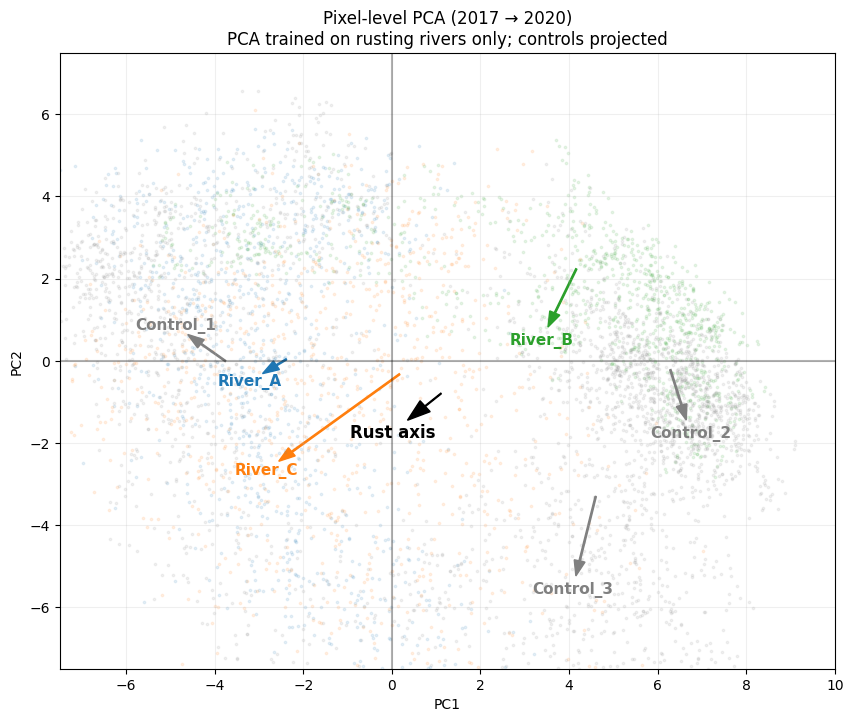

In [ ]:
# ============================================================
# TEST WITH 3 CONTROL RIVERS
# PCA FIT ONLY ON RUSTING RIVERS
# CONTROLS PROJECTED AFTERWARD (GREY VISUALISATION)
# ============================================================

import numpy as np
import rasterio
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from collections import defaultdict
import re

# ============================================================
# 1. INPUT PATHS
# ============================================================

paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif",
    "Control_1": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_1.tif",
    "Control_2": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_2.tif",
    "Control_3": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_4.tif"
}

rivers = list(paths.keys())

rusting_rivers = ["River_A", "River_B", "River_C"]

# ============================================================
# 2. LOAD MATCHED PIXELS (2017 & 2020)
# ============================================================

data_pairs = {}

def extract_year(name):

    if name is None:
        return None

    m = re.search(r"_(\d{4})_", name)

    return int(m.group(1)) if m else None


for r, path in paths.items():

    print(f"\nProcessing {r}")

    with rasterio.open(path) as src:

        years = np.array([
            extract_year(n)
            for n in src.descriptions
        ])

        groups = defaultdict(list)

        for i, y in enumerate(years):
            if y is not None:
                groups[y].append(i)

        if 2017 not in groups or 2020 not in groups:
            print(f"{r}: missing years")
            continue

        idx17 = [
            i + 1
            for i in sorted(groups[2017])[:64]
            if i + 1 <= src.count
        ]

        idx20 = [
            i + 1
            for i in sorted(groups[2020])[:64]
            if i + 1 <= src.count
        ]

        img17 = src.read(idx17).reshape(64, -1).T
        img20 = src.read(idx20).reshape(64, -1).T

        valid = (
            np.isfinite(img17).all(axis=1) &
            np.isfinite(img20).all(axis=1)
        )

        X17 = img17[valid]
        X20 = img20[valid]

        data_pairs[r] = (X17, X20)

        print(f"{r}: valid pixels = {X17.shape[0]}")

# ============================================================
# 3. BALANCE PIXELS ACROSS ALL RIVERS
# ============================================================

min_n = min(v[0].shape[0] for v in data_pairs.values())

print("\nBalanced pixels per river:", min_n)

X17_all = []
X20_all = []
labels = []

for r in rivers:

    X17, X20 = data_pairs[r]

    idx = np.random.choice(len(X17), min_n, replace=False)

    X17_all.append(X17[idx])
    X20_all.append(X20[idx])

    labels += [r] * min_n

X17_all = np.vstack(X17_all)
X20_all = np.vstack(X20_all)

labels = np.array(labels)

# ============================================================
# 4. PCA TRAINING DATA (RUSTING ONLY)
# ============================================================

rust_mask = np.isin(labels, rusting_rivers)

X_rust = np.vstack([
    X17_all[rust_mask],
    X20_all[rust_mask]
])

# ============================================================
# 5. STANDARDISATION (RUST ONLY)
# ============================================================

scaler = StandardScaler()
scaler.fit(X_rust)

X_all = np.vstack([X17_all, X20_all])
X_all_scaled = scaler.transform(X_all)

X_rust_scaled = scaler.transform(X_rust)

# ============================================================
# 6. PCA FIT (RUST ONLY)
# ============================================================

pca = PCA(n_components=2)
pca.fit(X_rust_scaled)

Z = pca.transform(X_all_scaled)

print("\nExplained variance:")
print(pca.explained_variance_ratio_)

# ============================================================
# 7. SPLIT INTO YEARS
# ============================================================

n_total = len(X17_all)

Z17 = Z[:n_total]
Z20 = Z[n_total:]

# ============================================================
# 8. DISPLACEMENTS
# ============================================================

D = Z20 - Z17
D_rust = D[rust_mask]

# ============================================================
# 9. RUST AXIS (SVD)
# ============================================================

U, S, Vt = np.linalg.svd(D_rust, full_matrices=False)
rust_axis = Vt[0]

if np.dot(D_rust.mean(axis=0), rust_axis) < 0:
    rust_axis = -rust_axis

# ============================================================
# 10. COSINE ALIGNMENT
# ============================================================

def cosine_to_axis(vecs, axis):
    mean_vec = vecs.mean(axis=0)
    return np.dot(mean_vec, axis) / (
        np.linalg.norm(mean_vec) * np.linalg.norm(axis) + 1e-12
    )

print("\nCOSINE ALIGNMENT WITH RUST AXIS\n")

for r in rivers:
    mask = labels == r
    score = cosine_to_axis(D[mask], rust_axis)
    print(f"{r}: {score:.4f}")

# ============================================================
# 11. PLOTTING
# ============================================================

plt.figure(figsize=(10, 8))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange",
    "Control_1": "grey",
    "Control_2": "grey",
    "Control_3": "grey"
}

start = 0

for r in rivers:

    Z17_r = Z17[start:start+min_n]
    Z20_r = Z20[start:start+min_n]

    c = colors[r]

    # -----------------------
    # 2017 CLOUD
    # -----------------------
    plt.scatter(Z17_r[:,0], Z17_r[:,1],
                s=3, alpha=0.1, color=c)

    # -----------------------
    # 2020 CLOUD
    # -----------------------
    plt.scatter(Z20_r[:,0], Z20_r[:,1],
                s=3, alpha=0.10, color=c)

    # -----------------------
    # MEAN SHIFT ARROW
    # -----------------------
    m17 = Z17_r.mean(axis=0)
    m20 = Z20_r.mean(axis=0)

    dx = m20[0] - m17[0]
    dy = m20[1] - m17[1]

    plt.arrow(
        m17[0], m17[1], dx, dy,
        color=c,
        width=0.03,
        head_width=0.25,
        length_includes_head=True
    )

    label_offset = 0.35

    arrow_len = np.sqrt(dx**2 + dy**2)

    if arrow_len > 0:
        offset_x = label_offset * dx / arrow_len
        offset_y = label_offset * dy / arrow_len
    else:
        offset_x = label_offset
        offset_y = label_offset

    plt.text(
        m20[0] + offset_x,
        m20[1] + offset_y,
        r,
        color=c,
        fontsize=11,
        weight='bold',
        ha='center',
        va='center'
    )

    start += min_n

# ============================================================
# 12. RUST AXIS
# ============================================================

origin = np.mean(Z, axis=0)

plt.arrow(
    origin[0], origin[1],
    rust_axis[0], rust_axis[1],
    color="black",
    width=0.02,
    head_width=0.35,
    length_includes_head=True
)

# I offset the rust-axis label slightly beyond the arrow tip.
rust_label_offset = 0.45

plt.text(
    origin[0] + rust_axis[0] * (1 + rust_label_offset),
    origin[1] + rust_axis[1] * (1 + rust_label_offset),
    "Rust axis",
    color="black",
    fontsize=12,
    weight='bold',
    ha='center',
    va='center'
)

# ============================================================
# 13. FINAL STYLE
# ============================================================

plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.xlim(-7.5, 10)
plt.ylim(-7.5, 7.5)

plt.title(
    "Pixel-level PCA (2017 → 2020)\n"
    "PCA trained on rusting rivers only; controls projected"
)

plt.grid(alpha=0.2)

plt.show()

The control rivers introduced seem to confirm the identification of a rust axis. Explained variance of Principal Component 1 (25%) and 2 (17%) are encouraging, considering the model is trained on 64 dimensions.

Rusting change in a coherent direction while controls differ. We previously established that control rivers, by their geographical proximity to the rusting rivers studied, share siginificant variability other than rusting that is detectable when performing PCA on embedding **changes**, with rusting rivers overlapping with their neighboring control rivers. Despite these similarities, the plot above seems to effectively isolate the rusting signal, as we observe that controls do not respond in the same way as their corresponding rusting counterparts. <br>

Cosine similarity scores show (in one interation of this code) 99.1, 90.1 and 99.9 % similarity for rusting rivers, and merely 20.9, 41.1 and 80.6 % for controls, suggesting that non-rusting rivers behave differently in the main variability mode learned from rusting rivers.

Limitations of this result are two-sided. Firstly, data is lacking on control rivers and there is a possibility that they may have been mislabelled using Sentinel-2 Data, as this was done visually. Hence, control_3 (~80% score) may in fact be a rusting river. Secondly, the main direction of change in 64D encompassed in PC1 and PC2 may be unrelated to rusting. The latter is unlikely considering rusting rivers and their counterparts are very similar in characteristics by design (Control 1 is the upstream non-rusting part of Agashashuk river!), essentially attributing differences in PCA to "rusting signal".

# Environmental cost estimate

This notebook uses a small subset of Google's AlphaEarth / Satellite Embedding dataset to analyse Arctic river rusting. The dataset is already precomputed in Google Earth Engine, meaning that this project does not train the AlphaEarth model or generate the global embedding product. The environmental cost considered here is therefore the marginal cost of:

1. extracting and clipping AlphaEarth embeddings in Google Earth Engine;
2. exporting and storing the extracted embedding data;
3. running the local Python notebook on CPU;
4. using ChatGPT for coding/debugging support during development.

Google Earth Engine describes the Satellite Embedding dataset as a global collection of annual 10 m geospatial embeddings, where each pixel contains a 64-dimensional embedding vector. Google DeepMind also describes the AlphaEarth-powered Satellite Embedding dataset as containing more than 1.4 trillion embedding footprints per year. This means that the main environmental cost of model training and global dataset generation is upstream of this notebook and cannot be attributed directly from the number of pixels used here. Google does not publish a per-pixel carbon or water footprint for AlphaEarth embeddings, so the estimate below is an order-of-magnitude marginal estimate rather than a formal life-cycle assessment.

In [21]:
# ============================================================
# Environmental cost estimate for this notebook
# ============================================================

import pandas as pd

# ============================================================
# 1. PROJECT-SPECIFIC PARAMETERS
# ============================================================

# Number of pixels used in the analysis
n_pixels = 16_000

# AlphaEarth / Satellite Embedding pixels have 64 dimensions
n_dimensions = 64

# Assume exported values are stored as float32
bytes_per_value = 4

# Main analysis compares 2017 and 2020
n_years_main_analysis = 2

# Full exported time series used/available in the project
n_years_full_export = 9

# Google Earth Engine extraction:
# 6 rivers, with each embedding extraction/clipping task taking ~15 minutes
n_rivers = 6
gee_minutes_per_river = 15
gee_total_minutes = n_rivers * gee_minutes_per_river
gee_total_hours = gee_total_minutes / 60

# Local notebook runtime:
# CarbonTracker estimated ~0.15 kWh per full notebook run.
# The notebook was run approximately 5–15 times during development,
# with a median estimate of 10 runs.
carbontracker_kwh_per_run = 0.15
notebook_runs_low = 5
notebook_runs_median = 10
notebook_runs_high = 15

# ChatGPT coding/debugging use:
# approximate number of coding-heavy queries used during development
n_chatgpt_queries = 200

### Data-volume estimate

For 16,000 pixels, the raw embedding volume is calculated as:

$$
\text{data size} = \text{pixels} \times \text{embedding dimensions} \times \text{years} \times \text{bytes per value}
$$

Assuming `float32` values, each embedding value uses 4 bytes. This does not include GeoTIFF metadata, compression, temporary Earth Engine processing, Google Drive overhead, or local filesystem overhead.

In [11]:
# ============================================================
# 2. DATA VOLUME
# ============================================================

def embedding_data_volume(n_pixels, n_dimensions, n_years, bytes_per_value=4):
    bytes_total = n_pixels * n_dimensions * n_years * bytes_per_value
    mb_total = bytes_total / 1e6
    gb_total = bytes_total / 1e9
    return bytes_total, mb_total, gb_total


data_scenarios = {
    "Main analysis: 2017 + 2020": n_years_main_analysis,
    "Full exported time series: 9 years": n_years_full_export
}

data_rows = []

for scenario, n_years in data_scenarios.items():
    bytes_total, mb_total, gb_total = embedding_data_volume(
        n_pixels=n_pixels,
        n_dimensions=n_dimensions,
        n_years=n_years,
        bytes_per_value=bytes_per_value
    )

    data_rows.append({
        "Scenario": scenario,
        "Years": n_years,
        "Raw data volume (MB)": mb_total,
        "Raw data volume (GB)": gb_total
    })

data_volume = pd.DataFrame(data_rows)
data_volume

,Scenario,Years,Raw data volume (MB),Raw data volume (GB)
0,Main analysis: 2017 + 2020,2,8.192,0.008192
1,Full exported time series: 9 years,9,36.864,0.036864


### Assumptions for energy and emissions

The following calculations estimate only marginal use. They do not include the upstream footprint of training AlphaEarth, producing the global embedding dataset, manufacturing hardware, or maintaining cloud infrastructure beyond simple operational approximations.

For data transfer, I use a conservative historical fixed-line internet transmission estimate of **0.06 kWh/GB** from Aslan et al. (2018). This is likely conservative for modern networks, but it provides a transparent upper-end approximation for small data movement.

For emissions, I use an illustrative electricity carbon intensity of **125 gCO₂/kWh**, based on Great Britain's 2024 average electricity carbon intensity. This is appropriate for the local CPU run if the notebook is run in the UK, but it is only illustrative for Google Earth Engine or ChatGPT because cloud workloads may run in different regions with different electricity mixes and carbon accounting methods.

For water, there is no AlphaEarth-, Earth Engine-, or ChatGPT-specific public water factor that can be reliably applied here. As an illustrative sensitivity value only, I use the water-to-energy ratio implied by Google's published Gemini Apps median text prompt estimate: 0.26 mL water for 0.24 Wh of energy. This is not a measurement of this notebook, Earth Engine, or ChatGPT; it is included only to make the calculation transparent and adjustable.

In [12]:
# ============================================================
# 3. GENERAL ASSUMPTIONS
# ============================================================

# Data transfer energy intensity:
# Aslan et al. estimated 0.06 kWh/GB for fixed-line internet transmission.
network_kwh_per_gb = 0.06

# Illustrative GB grid carbon intensity for 2024.
# Units: grams CO2 per kWh.
grid_gco2_per_kwh = 125

# Illustrative water factor derived from Google's Gemini Apps estimate:
# 0.26 mL water for 0.24 Wh = 1.083 L/kWh.
# This is NOT specific to Earth Engine, AlphaEarth, or ChatGPT.
water_l_per_kwh = 0.26 / 0.24

### Local notebook runs measured with CarbonTracker

CarbonTracker estimated that one full run of the notebook uses approximately **0.15 kWh**. During development, the notebook was run approximately **5–15 times**, with **10 runs** used as the median estimate.

This replaces a generic power-based estimate because it is based on a project-specific measurement rather than an assumed CPU wattage. The resulting local energy use is:

\[
\text{local energy} = 0.15 \text{ kWh per run} \times \text{number of runs}
\]

Therefore:

- low estimate: \(0.15 \times 5 = 0.75\) kWh
- median estimate: \(0.15 \times 10 = 1.50\) kWh
- high estimate: \(0.15 \times 15 = 2.25\) kWh

In [22]:
# ============================================================
# 4. LOCAL NOTEBOOK RUNS USING CARBONTRACKER
# ============================================================

local_run_scenarios = {
    "Low local estimate": notebook_runs_low,
    "Median local estimate": notebook_runs_median,
    "High local estimate": notebook_runs_high
}

local_rows = []

for scenario, n_runs in local_run_scenarios.items():

    kwh = carbontracker_kwh_per_run * n_runs
    gco2 = kwh * grid_gco2_per_kwh
    water_ml = kwh * water_l_per_kwh * 1000

    local_rows.append({
        "Component": "Local notebook runs measured with CarbonTracker",
        "Scenario": scenario,
        "Notebook runs": n_runs,
        "CarbonTracker energy per run (kWh)": carbontracker_kwh_per_run,
        "Estimated energy (kWh)": kwh,
        "Estimated emissions (g CO2)": gco2,
        "Illustrative water use (mL)": water_ml
    })

local_cpu_cost = pd.DataFrame(local_rows)
local_cpu_cost

,Component,Scenario,Notebook runs,CarbonTracker energy per run (kWh),Estimated energy (kWh),Estimated emissions (g CO2),Illustrative water use (mL)
0,Local notebook runs measured with CarbonTracker,Low local estimate,5,0.15,0.75,93.75,812.5
1,Local notebook runs measured with CarbonTracker,Median local estimate,10,0.15,1.50,187.50,1625.0
2,Local notebook runs measured with CarbonTracker,High local estimate,15,0.15,2.25,281.25,2437.5


However, the carbon tracker run on this notebook sugest much higher values for CPU energy use, totalling 0.15 kWh for the entire notebook (which is run approximately 25 times during testing). This suggest a real energy use of 3.75 kWh for this section!

### Google Earth Engine extraction and clipping

The embedding extraction stage uses Google Earth Engine to extract AlphaEarth embeddings for **6 rivers**, clipping each embedding stack to manually drawn river polygons. Each river extraction task takes approximately **15 minutes**, giving a total Earth Engine task time of approximately:

$$
6 \text{ rivers} \times 15 \text{ minutes per river} = 90 \text{ minutes}
$$

The real environmental cost of Earth Engine extraction is difficult to estimate from task time alone because Earth Engine is a managed cloud platform: work may be parallelised, scheduled across different machines, and executed in data centres with unknown region-specific power use. Therefore, I model this using a sensitivity range for the effective cloud power associated with the extraction task. This is not a measured Google Earth Engine footprint.

The central estimate assumes an effective **150 W** cloud workload over the 90 minutes. A lower value of **50 W** and an upper value of **500 W** are included to show the effect of uncertainty.

In [14]:
# ============================================================
# 5. GOOGLE EARTH ENGINE EXTRACTION / CLIPPING
# ============================================================

gee_effective_power_scenarios_watts = {
    "Low GEE estimate": 50,
    "Central GEE estimate": 150,
    "High GEE estimate": 500
}

gee_rows = []

for scenario, watts in gee_effective_power_scenarios_watts.items():

    kwh = (watts / 1000) * gee_total_hours
    gco2 = kwh * grid_gco2_per_kwh
    water_ml = kwh * water_l_per_kwh * 1000

    gee_rows.append({
        "Component": "Google Earth Engine extraction and clipping",
        "Scenario": scenario,
        "Number of rivers": n_rivers,
        "Task time per river (minutes)": gee_minutes_per_river,
        "Total task time (minutes)": gee_total_minutes,
        "Assumed effective power (W)": watts,
        "Estimated energy (kWh)": kwh,
        "Estimated emissions (g CO2)": gco2,
        "Illustrative water use (mL)": water_ml
    })

gee_cost = pd.DataFrame(gee_rows)
gee_cost

,Component,Scenario,Number of rivers,Task time per river (minutes),Total task time (minutes),Assumed effective power (W),Estimated energy (kWh),Estimated emissions (g CO2),Illustrative water use (mL)
0,Google Earth Engine extraction and clipping,Low GEE estimate,6,15,90,50,0.075,9.375,81.25
1,Google Earth Engine extraction and clipping,Central GEE estimate,6,15,90,150,0.225,28.125,243.75
2,Google Earth Engine extraction and clipping,High GEE estimate,6,15,90,500,0.750,93.750,812.50


### Data transfer and storage

The data exported from Earth Engine is small. For the full 9-year export, 16000 pixels corresponds to approximately **36.9 MB**.

Because these files are small, the estimated energy and emissions associated with data transfer are negligible compared with cloud processing and AI-assisted coding/debugging.

In [15]:
# ============================================================
# 6. DATA TRANSFER
# ============================================================

transfer_rows = []

for _, row in data_volume.iterrows():

    gb_total = row["Raw data volume (GB)"]
    kwh = gb_total * network_kwh_per_gb
    gco2 = kwh * grid_gco2_per_kwh
    water_ml = kwh * water_l_per_kwh * 1000

    transfer_rows.append({
        "Component": "Data transfer",
        "Scenario": row["Scenario"],
        "Raw data volume (MB)": row["Raw data volume (MB)"],
        "Raw data volume (GB)": gb_total,
        "Estimated transfer energy (kWh)": kwh,
        "Estimated transfer emissions (g CO2)": gco2,
        "Illustrative water use (mL)": water_ml
    })

transfer_cost = pd.DataFrame(transfer_rows)
transfer_cost

,Component,Scenario,Raw data volume (MB),Raw data volume (GB),Estimated transfer energy (kWh),Estimated transfer emissions (g CO2),Illustrative water use (mL)
0,Data transfer,Main analysis: 2017 + 2020,8.192,0.008192,0.000492,0.06144,0.53248
1,Data transfer,Full exported time series: 9 years,36.864,0.036864,0.002212,0.27648,2.39616


### ChatGPT-assisted coding and debugging

During development, approximately **200 coding-heavy ChatGPT queries** were used for debugging and code refinement. There is no public, model-specific, officially auditable environmental factor for the exact ChatGPT queries used here. Query impact depends on many factors.

I estimate ChatGPT use footprint with the Washington Post's estimate of 0.3 Wh per prompt as a minimum. Considering the complexity of coding uses made, an upper bound is also defined.

In [23]:
# ============================================================
# 7. CHATGPT CODING / DEBUGGING SUPPORT
# ============================================================

chatgpt_energy_scenarios_wh_per_query = {
    "Low AI-query estimate": 0.3,
    "High coding-query estimate": 3.0
}

chatgpt_rows = []

for scenario, wh_per_query in chatgpt_energy_scenarios_wh_per_query.items():

    kwh = (n_chatgpt_queries * wh_per_query) / 1000
    gco2 = kwh * grid_gco2_per_kwh
    water_ml = kwh * water_l_per_kwh * 1000

    chatgpt_rows.append({
        "Component": "ChatGPT coding/debugging queries",
        "Scenario": scenario,
        "Number of queries": n_chatgpt_queries,
        "Assumed energy per query (Wh)": wh_per_query,
        "Estimated energy (kWh)": kwh,
        "Estimated emissions (g CO2)": gco2,
        "Illustrative water use (mL)": water_ml
    })

chatgpt_cost = pd.DataFrame(chatgpt_rows)
chatgpt_cost

,Component,Scenario,Number of queries,Assumed energy per query (Wh),Estimated energy (kWh),Estimated emissions (g CO2),Illustrative water use (mL)
0,ChatGPT coding/debugging queries,Low AI-query estimate,200,0.3,0.06,7.5,65.0
1,ChatGPT coding/debugging queries,High coding-query estimate,200,3.0,0.60,75.0,650.0


### Combined marginal estimate

The combined estimate below adds:

1. Google Earth Engine extraction and clipping;
2. transfer of the full 9-year exported embedding subset;
3. local CPU execution of the notebook;
4. ChatGPT-assisted coding/debugging queries.

For the combined estimate, the low, central and high cases are matched across each component. This gives a transparent range rather than a single over-precise value.

In [24]:
# ============================================================
# 8. COMBINED LOW / CENTRAL / HIGH ESTIMATE
# ============================================================

# Use the full 9-year export for the transfer component,
# because this better represents the project extraction/export stage.
transfer_full = transfer_cost[
    transfer_cost["Scenario"] == "Full exported time series: 9 years"
].iloc[0]

combined_scenarios = {
    "Low estimate": {
        "gee_power_w": 50,
        "notebook_runs": notebook_runs_low,
        "chatgpt_wh_per_query": 0.3
    },
    "Central estimate": {
        "gee_power_w": 150,
        "notebook_runs": notebook_runs_median,
        "chatgpt_wh_per_query": 1.15
    },
    "High estimate": {
        "gee_power_w": 500,
        "notebook_runs": notebook_runs_high,
        "chatgpt_wh_per_query": 3
    }
}

combined_rows = []

for scenario, assumptions in combined_scenarios.items():

    # GEE extraction
    gee_kwh = (assumptions["gee_power_w"] / 1000) * gee_total_hours

    # Local notebook runs, measured with CarbonTracker
    local_kwh = carbontracker_kwh_per_run * assumptions["notebook_runs"]

    # Data transfer
    transfer_kwh = transfer_full["Estimated transfer energy (kWh)"]

    # ChatGPT coding/debugging
    chatgpt_kwh = (n_chatgpt_queries * assumptions["chatgpt_wh_per_query"]) / 1000

    # Total
    total_kwh = gee_kwh + local_kwh + transfer_kwh + chatgpt_kwh
    total_gco2 = total_kwh * grid_gco2_per_kwh
    total_water_ml = total_kwh * water_l_per_kwh * 1000

    combined_rows.append({
        "Scenario": scenario,
        "GEE extraction energy (kWh)": gee_kwh,
        "Local notebook energy (kWh)": local_kwh,
        "Data transfer energy (kWh)": transfer_kwh,
        "ChatGPT debugging energy (kWh)": chatgpt_kwh,
        "Total estimated energy (kWh)": total_kwh,
        "Total estimated emissions (g CO2)": total_gco2,
        "Illustrative total water use (mL)": total_water_ml
    })

combined_cost = pd.DataFrame(combined_rows)
combined_cost

,Scenario,GEE extraction energy (kWh),Local notebook energy (kWh),Data transfer energy (kWh),ChatGPT debugging energy (kWh),Total estimated energy (kWh),Total estimated emissions (g CO2),Illustrative total water use (mL)
0,Low estimate,0.075,0.75,0.002212,0.06,0.887212,110.90148,961.146160
1,Central estimate,0.225,1.50,0.002212,0.23,1.957212,244.65148,2120.312827
2,High estimate,0.750,2.25,0.002212,0.60,3.602212,450.27648,3902.396160


The final median estimate is ~ 250 g CO2 and ~ 2 L of water, excluding footprint of upstream embedding computation as well as infrastructure costs.

### References for Environmental Footprint

Google Earth Engine Data Catalog. *Satellite Embedding V1: GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL*.  
https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL

Google DeepMind. *AlphaEarth Foundations helps map our planet in unprecedented detail*.  
https://deepmind.google/blog/alphaearth-foundations-helps-map-our-planet-in-unprecedented-detail/

Aslan, J., Mayers, K., Koomey, J. G., & France, C. (2018). *Electricity Intensity of Internet Data Transmission: Untangling the Estimates*. Journal of Industrial Ecology, 22(4), 785–798.  
https://doi.org/10.1111/jiec.12630

National Energy System Operator. *Britain's Electricity Explained: 2024 Review*.  
https://www.neso.energy/news/britains-electricity-explained-2024-review

Google Cloud. *Measuring the environmental impact of AI inference*.  
https://cloud.google.com/blog/products/infrastructure/measuring-the-environmental-impact-of-ai-inference/

Google Cloud. *Carbon Footprint*.  
https://cloud.google.com/carbon-footprint

Google Cloud. *Carbon Footprint reporting methodology*.  
https://docs.cloud.google.com/carbon-footprint/docs/methodology